# Shrub Detection Pipeline

End-to-end notebook for the V12 XGBoost shrub detection pipeline.

**Stages:**
1. Environment & package check
2. Artifact & input file check
3. SAM annotation summary (re-annotation requires SAM checkpoint)
4. V12 XGBoost training (optional — skipped if model already exists)
5. V12 prediction — all 6 sites
6. Results visualisation

> **Run environment:** WSL Ubuntu with `venv_linux` activated, or any Linux Python 3.10+ env.

---
## 1. Environment & Package Check

In [1]:
import importlib, sys
from pathlib import Path

REQUIRED = {
    "numpy":             "numpy",
    "pandas":            "pandas",
    "scipy":             "scipy",
    "sklearn":           "scikit-learn",
    "xgboost":           "xgboost",
    "optuna":            "optuna",
    "joblib":            "joblib",
    "rasterio":          "rasterio",
    "geopandas":         "geopandas",
    "shapely":           "shapely",
    "cv2":               "opencv-python",
    "matplotlib":        "matplotlib",
    "torch":             "torch",
    "torchvision":       "torchvision",
    "PIL":               "Pillow",
    "planetary_computer": "planetary-computer",
    "pystac_client":     "pystac-client",
}

OPTIONAL = {
    "ee":                "earthengine-api",
    "segment_anything":  "segment-anything",
}

print(f"Python: {sys.version.split()[0]}")
print()

all_ok = True
for mod, pkg in REQUIRED.items():
    try:
        m = importlib.import_module(mod)
        ver = getattr(m, "__version__", "?")
        print(f"  ✓  {pkg:<25} {ver}")
    except ImportError:
        print(f"  ✗  {pkg:<25} MISSING — pip install {pkg}")
        all_ok = False

print()
print("Optional:")
for mod, pkg in OPTIONAL.items():
    try:
        m = importlib.import_module(mod)
        ver = getattr(m, "__version__", "?")
        print(f"  ✓  {pkg:<25} {ver}")
    except ImportError:
        print(f"  -  {pkg:<25} not installed (optional)")

print()
if all_ok:
    print("✅ All required packages present.")
else:
    print("❌ Some required packages are missing. Install them before continuing.")

Python: 3.12.3

  ✓  numpy                     2.2.0
  ✓  pandas                    2.2.2
  ✓  scipy                     1.15.2
  ✓  scikit-learn              1.6.1
  ✓  xgboost                   3.2.0
  ✓  optuna                    4.8.0
  ✓  joblib                    1.4.2
  ✓  rasterio                  1.4.3
  ✓  geopandas                 1.1.3
  ✓  shapely                   2.1.2
  ✓  opencv-python             4.13.0
  ✓  matplotlib                3.9.0
  ✓  torch                     2.5.1+cu121
  ✓  torchvision               0.20.1+cu121
  ✓  Pillow                    11.2.1
  ✓  planetary-computer        1.0.0
  ✓  pystac-client             0.9.0

Optional:
  ✓  earthengine-api           1.7.15
  -  segment-anything          not installed (optional)

✅ All required packages present.


In [2]:
import torch
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")
    print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA available : True
GPU            : NVIDIA GeForce RTX 3070 Ti
VRAM           : 8.6 GB


---
## 2. Artifact & Input File Check

In [3]:
import os
BASE = Path(".")  # adjust if running from a different directory

# --- Model artifacts ---
ARTIFACTS = {
    "V12 classifier":        BASE / "shrub_classifier_v12.joblib",
    "V12 scaler":            BASE / "shrub_scaler_v12.joblib",
    "V12 meta":              BASE / "v12_model_meta.json",
    "SAM train JSON":        BASE / "detectron2_dataset/shrub_train_sam.json",
    "SAM val JSON":          BASE / "detectron2_dataset/shrub_val_sam.json",
    "SAM checkpoint (opt.)": BASE / "sam_vit_h_4b8939.pth",
}

print("Model artifacts:")
for name, path in ARTIFACTS.items():
    exists = path.exists()
    size   = f"{path.stat().st_size/1e6:.1f} MB" if exists else ""
    mark   = "✓" if exists else ("-" if "opt" in name else "✗")
    print(f"  {mark}  {name:<30} {size}")

MODEL_READY = all(
    (BASE / f).exists() for f in [
        "shrub_classifier_v12.joblib",
        "shrub_scaler_v12.joblib",
        "v12_model_meta.json",
    ]
)
print()
print("Model ready for inference:", "✅" if MODEL_READY else "❌ (run training cell below)")

Model artifacts:
  ✓  V12 classifier                 0.8 MB
  ✓  V12 scaler                     0.0 MB
  ✓  V12 meta                       0.0 MB
  ✓  SAM train JSON                 30.5 MB
  ✓  SAM val JSON                   9.4 MB
  -  SAM checkpoint (opt.)          

Model ready for inference: ✅


In [4]:
SITES = {
    "Calaveras_Big_trees": {
        "naip": "calaveras_big_trees_1m_naip_2022.tif",
        "chm":  "calaveras_big_trees_canopy_height_1m.tif",
    },
    "DL_Bliss": {
        "naip": "dl_bliss_1m_naip_2022.tif",
        "chm":  "dl_bliss_canopy_height_1m.tif",
    },
    "Independence_Lake": {
        "naip": "independence_lake_1m_naip_2022.tif",
        "chm":  "independence_lake_canopy_height_1m.tif",
    },
    "Pacific_Union": {
        "naip": "pacific_union_college_1m_naip_2022.tif",
        "chm":  "pacific_union_canopy_height_1m.tif",
    },
    "Sedgwick": {
        "naip": "sedgwick_1m_naip_2022.tif",
        "chm":  "sedgwick_canopy_height_1m.tif",
    },
    "Shaver_Lake": {
        "naip": "shaver_lake_1m_naip_2022.tif",
        "chm":  "shaver_lake_canopy_height_1m.tif",
    },
}

print(f"{'Site':<25} {'NAIP':^6} {'CHM':^6}")
print("-" * 40)
sites_ready = []
for site, cfg in SITES.items():
    naip_dir = BASE / site / "NAIP_3DEP_product"
    naip_ok  = (naip_dir / cfg["naip"]).exists()
    chm_ok   = (naip_dir / cfg["chm"]).exists()
    both_ok  = naip_ok and chm_ok
    if both_ok:
        sites_ready.append(site)
    print(f"{site:<25} {'✓' if naip_ok else '✗':^6} {'✓' if chm_ok else '✗':^6}")

print()
print(f"{len(sites_ready)}/6 sites ready for prediction.")

Site                       NAIP   CHM  
----------------------------------------
Calaveras_Big_trees         ✓      ✓   
DL_Bliss                    ✓      ✓   
Independence_Lake           ✓      ✓   
Pacific_Union               ✓      ✓   
Sedgwick                    ✓      ✓   
Shaver_Lake                 ✓      ✓   

6/6 sites ready for prediction.


---
## 3. SAM Annotation Summary

SAM annotation (`sam_annotate.py`) refines circular shrub masks and mines tree/rock hard negatives.
Re-running requires the SAM ViT-H checkpoint (`sam_vit_h_4b8939.pth`, ~2.5 GB).

The cell below shows stats from the existing annotation run.

In [5]:
import json

sam_stats_path = BASE / "detectron2_dataset/sam_stats.json"
train_json     = BASE / "detectron2_dataset/shrub_train_sam.json"
val_json       = BASE / "detectron2_dataset/shrub_val_sam.json"

if sam_stats_path.exists():
    with open(sam_stats_path) as f:
        stats = json.load(f)
    for split, s in stats.items():
        print(f"{split.upper()}:")
        for k, v in s.items():
            print(f"  {k:<20} {v}")
        print()
else:
    print("sam_stats.json not found — SAM annotation has not been run yet.")

# Annotation counts from JSON
for name, path in [("Train", train_json), ("Val", val_json)]:
    if path.exists():
        with open(path) as f:
            data = json.load(f)
        n_patches = len(data)
        all_anns  = [a for d in data for a in d.get("annotations", [])]
        shrubs = sum(1 for a in all_anns if a.get("category_id") == 0)
        trees  = sum(1 for a in all_anns if a.get("category_id") == 1)
        rocks  = sum(1 for a in all_anns if a.get("category_id") == 2)
        print(f"{name}: {n_patches} patches | shrub={shrubs} tree={trees} rock={rocks} (total={len(all_anns)})")

sam_ckpt = BASE / "sam_vit_h_4b8939.pth"
print()
if sam_ckpt.exists():
    print("SAM checkpoint found — re-annotation can be run with sam_annotate.py")
else:
    print("⚠️  SAM checkpoint not found. To re-annotate, download sam_vit_h_4b8939.pth from:")
    print("   https://github.com/facebookresearch/segment-anything#model-checkpoints")

TRAIN:
  refined              440
  kept_original        1718
  trees                88272
  rocks                27750
  skipped              0

VAL:
  refined              413
  kept_original        1989
  trees                29728
  rocks                7281
  skipped              0

Train: 677 patches | shrub=2158 tree=88272 rock=27750 (total=118180)
Val: 202 patches | shrub=2402 tree=29728 rock=7281 (total=39411)

⚠️  SAM checkpoint not found. To re-annotate, download sam_vit_h_4b8939.pth from:
   https://github.com/facebookresearch/segment-anything#model-checkpoints


---
## 4. V12 XGBoost Training

Skipped if `shrub_classifier_v12.joblib` already exists. Set `FORCE_RETRAIN = True` to retrain from scratch.

In [6]:
FORCE_RETRAIN = False  # set True to retrain even if model exists

model_path = BASE / "shrub_classifier_v12.joblib"

if model_path.exists() and not FORCE_RETRAIN:
    print(f"✅ Model already exists at {model_path} — skipping training.")
    print("   Set FORCE_RETRAIN = True in this cell to retrain.")
else:
    print("Starting V12 training (this takes ~10–20 min with Optuna) ...")
    import subprocess, sys
    result = subprocess.run(
        [sys.executable, str(BASE / "train_shrub_v12.py")],
        capture_output=False,
    )
    if result.returncode == 0:
        print("\n✅ Training complete.")
    else:
        print(f"\n❌ Training failed with exit code {result.returncode}")

✅ Model already exists at shrub_classifier_v12.joblib — skipping training.
   Set FORCE_RETRAIN = True in this cell to retrain.


In [7]:
# Show saved V12 metrics
meta_path = BASE / "v12_model_meta.json"
if meta_path.exists():
    with open(meta_path) as f:
        meta = json.load(f)
    print(f"V12 model  |  {len(meta['features'])} features  |  threshold={meta['cls_threshold']}")
    print(f"  no_scale_features : {meta.get('no_scale_features', [])}")
    print()
    print("Validation metrics:")
    for k, v in meta["metrics"].items():
        print(f"  {k:<12} {v:.4f}")
    print()
    print("Top 10 features:")
    for i, f in enumerate(meta["features"][:10], 1):
        print(f"  {i:2}. {f}")

V12 model  |  20 features  |  threshold=0.5443
  no_scale_features : ['canopy_in_shrub_range']

Validation metrics:
  auc          0.7723
  precision    0.7533
  recall       0.9065
  f1           0.8229

Top 10 features:
   1. canopy_height_7x7mean
   2. canopy_height_5x5mean
   3. naip_red_5x5std
   4. brightness_7x7std
   5. canopy_height_3x3mean
   6. naip_red_3x3std
   7. brightness_5x5std
   8. canopy_height_7x7std
   9. canopy_shrub_clipped
  10. savi_7x7std


---
## 5. V12 Prediction — All Sites

In [8]:
import sys
sys.path.insert(0, str(BASE))

import joblib
import numpy as np
from predict_raster_v12 import run_shrub_prediction_v12

# Load model once
model  = joblib.load(BASE / "shrub_classifier_v12.joblib")
scaler = joblib.load(BASE / "shrub_scaler_v12.joblib")
with open(BASE / "v12_model_meta.json") as f:
    meta = json.load(f)

print(f"Model loaded  |  {type(model).__name__}")
print(f"Features      :  {meta['features']}")

Model loaded  |  XGBClassifier
Features      :  ['canopy_height_7x7mean', 'canopy_height_5x5mean', 'naip_red_5x5std', 'brightness_7x7std', 'canopy_height_3x3mean', 'naip_red_3x3std', 'brightness_5x5std', 'canopy_height_7x7std', 'canopy_shrub_clipped', 'savi_7x7std', 'canopy_in_shrub_range', 'naip_red_7x7std', 'greenness_ratio', 'brightness_3x3mean', 'savi_7x7mean', 'naip_nir_7x7std', 'naip_green_3x3std', 'ndvi_7x7mean', 'canopy_height_5x5std', 'gndvi']


c:\Users\sefak\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [9]:
import time

OUT_ROOT = BASE / "predictions_v12"
OUT_ROOT.mkdir(exist_ok=True)

results = []
t_total = time.time()

for site in sites_ready:
    cfg      = SITES[site]
    naip_dir = BASE / site / "NAIP_3DEP_product"
    naip_p   = naip_dir / cfg["naip"]
    chm_p    = naip_dir / cfg["chm"]
    out_dir  = OUT_ROOT / site
    out_dir.mkdir(exist_ok=True)
    prefix   = site.lower().replace(" ", "_")
    out_p    = out_dir / f"{prefix}_v12_mask.tif"

    print(f"\n{'='*55}")
    print(f"SITE: {site}")
    print(f"{'='*55}")
    t0 = time.time()

    run_shrub_prediction_v12(
        naip_path=str(naip_p),
        chm_path=str(chm_p),
        output_path=str(out_p),
    )

    elapsed = time.time() - t0

    # Read result for summary
    import rasterio
    with rasterio.open(out_p) as src:
        binary = src.read(1)
        H, W   = src.height, src.width

    shrub_px = int((binary == 1).sum())
    prob_p   = out_dir / f"{prefix}_v12_prob.tif"
    with rasterio.open(prob_p) as src:
        prob = src.read(1)

    results.append({
        "site":     site,
        "size":     f"{H}×{W}",
        "shrub_ha": round(shrub_px / 1e4, 2),
        "p50":      round(float(np.percentile(prob, 50)), 3),
        "p95":      round(float(np.percentile(prob, 95)), 3),
        "elapsed":  round(elapsed, 1),
        "prob_map": prob,
        "mask":     binary,
    })

print(f"\nTotal time: {(time.time()-t_total):.0f}s")


SITE: Calaveras_Big_trees
Loading V12 XGBoost model...
  20 features  no_scale=['canopy_in_shrub_range']  threshold=0.5443

Reading input rasters...
  Raster dimensions: 1537 × 4107 = 6,312,459 pixels

Computing spectral indices + canopy features...
Computing multi-scale textures...
  Textures done in 1.5s

Building feature matrix...
Running XGBoost inference...
  Inference complete in 0.2s
  Probability stats:  p50=0.3936  p95=0.8510  p99=0.9260

Applying threshold 0.5443...
  Shrub pixels: 1,824,769  (28.91% of raster)
  Saved binary mask : predictions_v12\Calaveras_Big_trees\calaveras_big_trees_v12_mask.tif
  Saved probability : predictions_v12\Calaveras_Big_trees\calaveras_big_trees_v12_prob.tif
V12 inference complete.

SITE: DL_Bliss
Loading V12 XGBoost model...
  20 features  no_scale=['canopy_in_shrub_range']  threshold=0.5443

Reading input rasters...


c:\Users\sefak\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


  Raster dimensions: 1124 × 578 = 649,672 pixels

Computing spectral indices + canopy features...
Computing multi-scale textures...
  Textures done in 0.1s

Building feature matrix...
Running XGBoost inference...
  Inference complete in 0.0s
  Probability stats:  p50=0.6674  p95=0.9152  p99=0.9327

Applying threshold 0.5443...
  Shrub pixels: 408,187  (62.83% of raster)
  Saved binary mask : predictions_v12\DL_Bliss\dl_bliss_v12_mask.tif
  Saved probability : predictions_v12\DL_Bliss\dl_bliss_v12_prob.tif
V12 inference complete.

SITE: Independence_Lake
Loading V12 XGBoost model...
  20 features  no_scale=['canopy_in_shrub_range']  threshold=0.5443

Reading input rasters...


c:\Users\sefak\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


  Raster dimensions: 1161 × 1760 = 2,043,360 pixels

Computing spectral indices + canopy features...
Computing multi-scale textures...
  Textures done in 0.4s

Building feature matrix...
Running XGBoost inference...
  Inference complete in 0.1s
  Probability stats:  p50=0.7333  p95=0.9215  p99=0.9337

Applying threshold 0.5443...
  Shrub pixels: 1,513,039  (74.05% of raster)
  Saved binary mask : predictions_v12\Independence_Lake\independence_lake_v12_mask.tif
  Saved probability : predictions_v12\Independence_Lake\independence_lake_v12_prob.tif
V12 inference complete.

SITE: Pacific_Union
Loading V12 XGBoost model...
  20 features  no_scale=['canopy_in_shrub_range']  threshold=0.5443

Reading input rasters...


...

  Raster dimensions: 2716 × 1087 = 2,952,292 pixels

Computing spectral indices + canopy features...
Computing multi-scale textures...
  Textures done in 0.7s

Building feature matrix...
Running XGBoost inference...
  Inference complete in 0.1s
  Probability stats:  p50=0.7352  p95=0.8888  p99=0.9430

Applying threshold 0.5443...
  Shrub pixels: 2,191,196  (74.22% of raster)
  Saved binary mask : predictions_v12\Pacific_Union\pacific_union_v12_mask.tif
  Saved probability : predictions_v12\Pacific_Union\pacific_union_v12_prob.tif
V12 inference complete.

SITE: Sedgwick
Loading V12 XGBoost model...
  20 features  no_scale=['canopy_in_shrub_range']  threshold=0.5443

Reading input rasters...


c:\Users\sefak\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


  Raster dimensions: 1815 × 589 = 1,069,035 pixels

Computing spectral indices + canopy features...
Computing multi-scale textures...
  Textures done in 0.3s

Building feature matrix...
Running XGBoost inference...
  Inference complete in 0.0s
  Probability stats:  p50=0.8721  p95=0.9452  p99=0.9476

Applying threshold 0.5443...
  Shrub pixels: 1,038,506  (97.14% of raster)
  Saved binary mask : predictions_v12\Sedgwick\sedgwick_v12_mask.tif
  Saved probability : predictions_v12\Sedgwick\sedgwick_v12_prob.tif
V12 inference complete.

SITE: Shaver_Lake
Loading V12 XGBoost model...
  20 features  no_scale=['canopy_in_shrub_range']  threshold=0.5443

Reading input rasters...
  Raster dimensions: 1078 × 531 = 572,418 pixels

Computing spectral indices + canopy features...


c:\Users\sefak\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RobustScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Computing multi-scale textures...
  Textures done in 0.1s

Building feature matrix...
Running XGBoost inference...
  Inference complete in 0.0s
  Probability stats:  p50=0.6548  p95=0.9090  p99=0.9359

Applying threshold 0.5443...
  Shrub pixels: 356,116  (62.21% of raster)
  Saved binary mask : predictions_v12\Shaver_Lake\shaver_lake_v12_mask.tif
  Saved probability : predictions_v12\Shaver_Lake\shaver_lake_v12_prob.tif
V12 inference complete.

Total time: 12s


In [10]:
# Summary table
print(f"\n{'='*65}")
print(f"SUMMARY  (threshold={meta['cls_threshold']})")
print(f"{'='*65}")
print(f"{'Site':<25} {'Size':>12} {'Shrub ha':>10} {'p50':>6} {'p95':>6} {'Time':>7}")
print("-" * 65)
for r in results:
    print(f"{r['site']:<25} {r['size']:>12} {r['shrub_ha']:>10.2f} "
          f"{r['p50']:>6.3f} {r['p95']:>6.3f} {r['elapsed']:>6.1f}s")


SUMMARY  (threshold=0.5443)
Site                              Size   Shrub ha    p50    p95    Time
-----------------------------------------------------------------
Calaveras_Big_trees          1537×4107     182.48  0.394  0.851    5.6s
DL_Bliss                      1124×578      40.82  0.667  0.915    0.5s
Independence_Lake            1161×1760     151.30  0.733  0.921    1.5s
Pacific_Union                2716×1087     219.12  0.735  0.889    2.4s
Sedgwick                      1815×589     103.85  0.872  0.945    1.1s
Shaver_Lake                   1078×531      35.61  0.655  0.909    0.4s


---
## 6. Results Visualisation

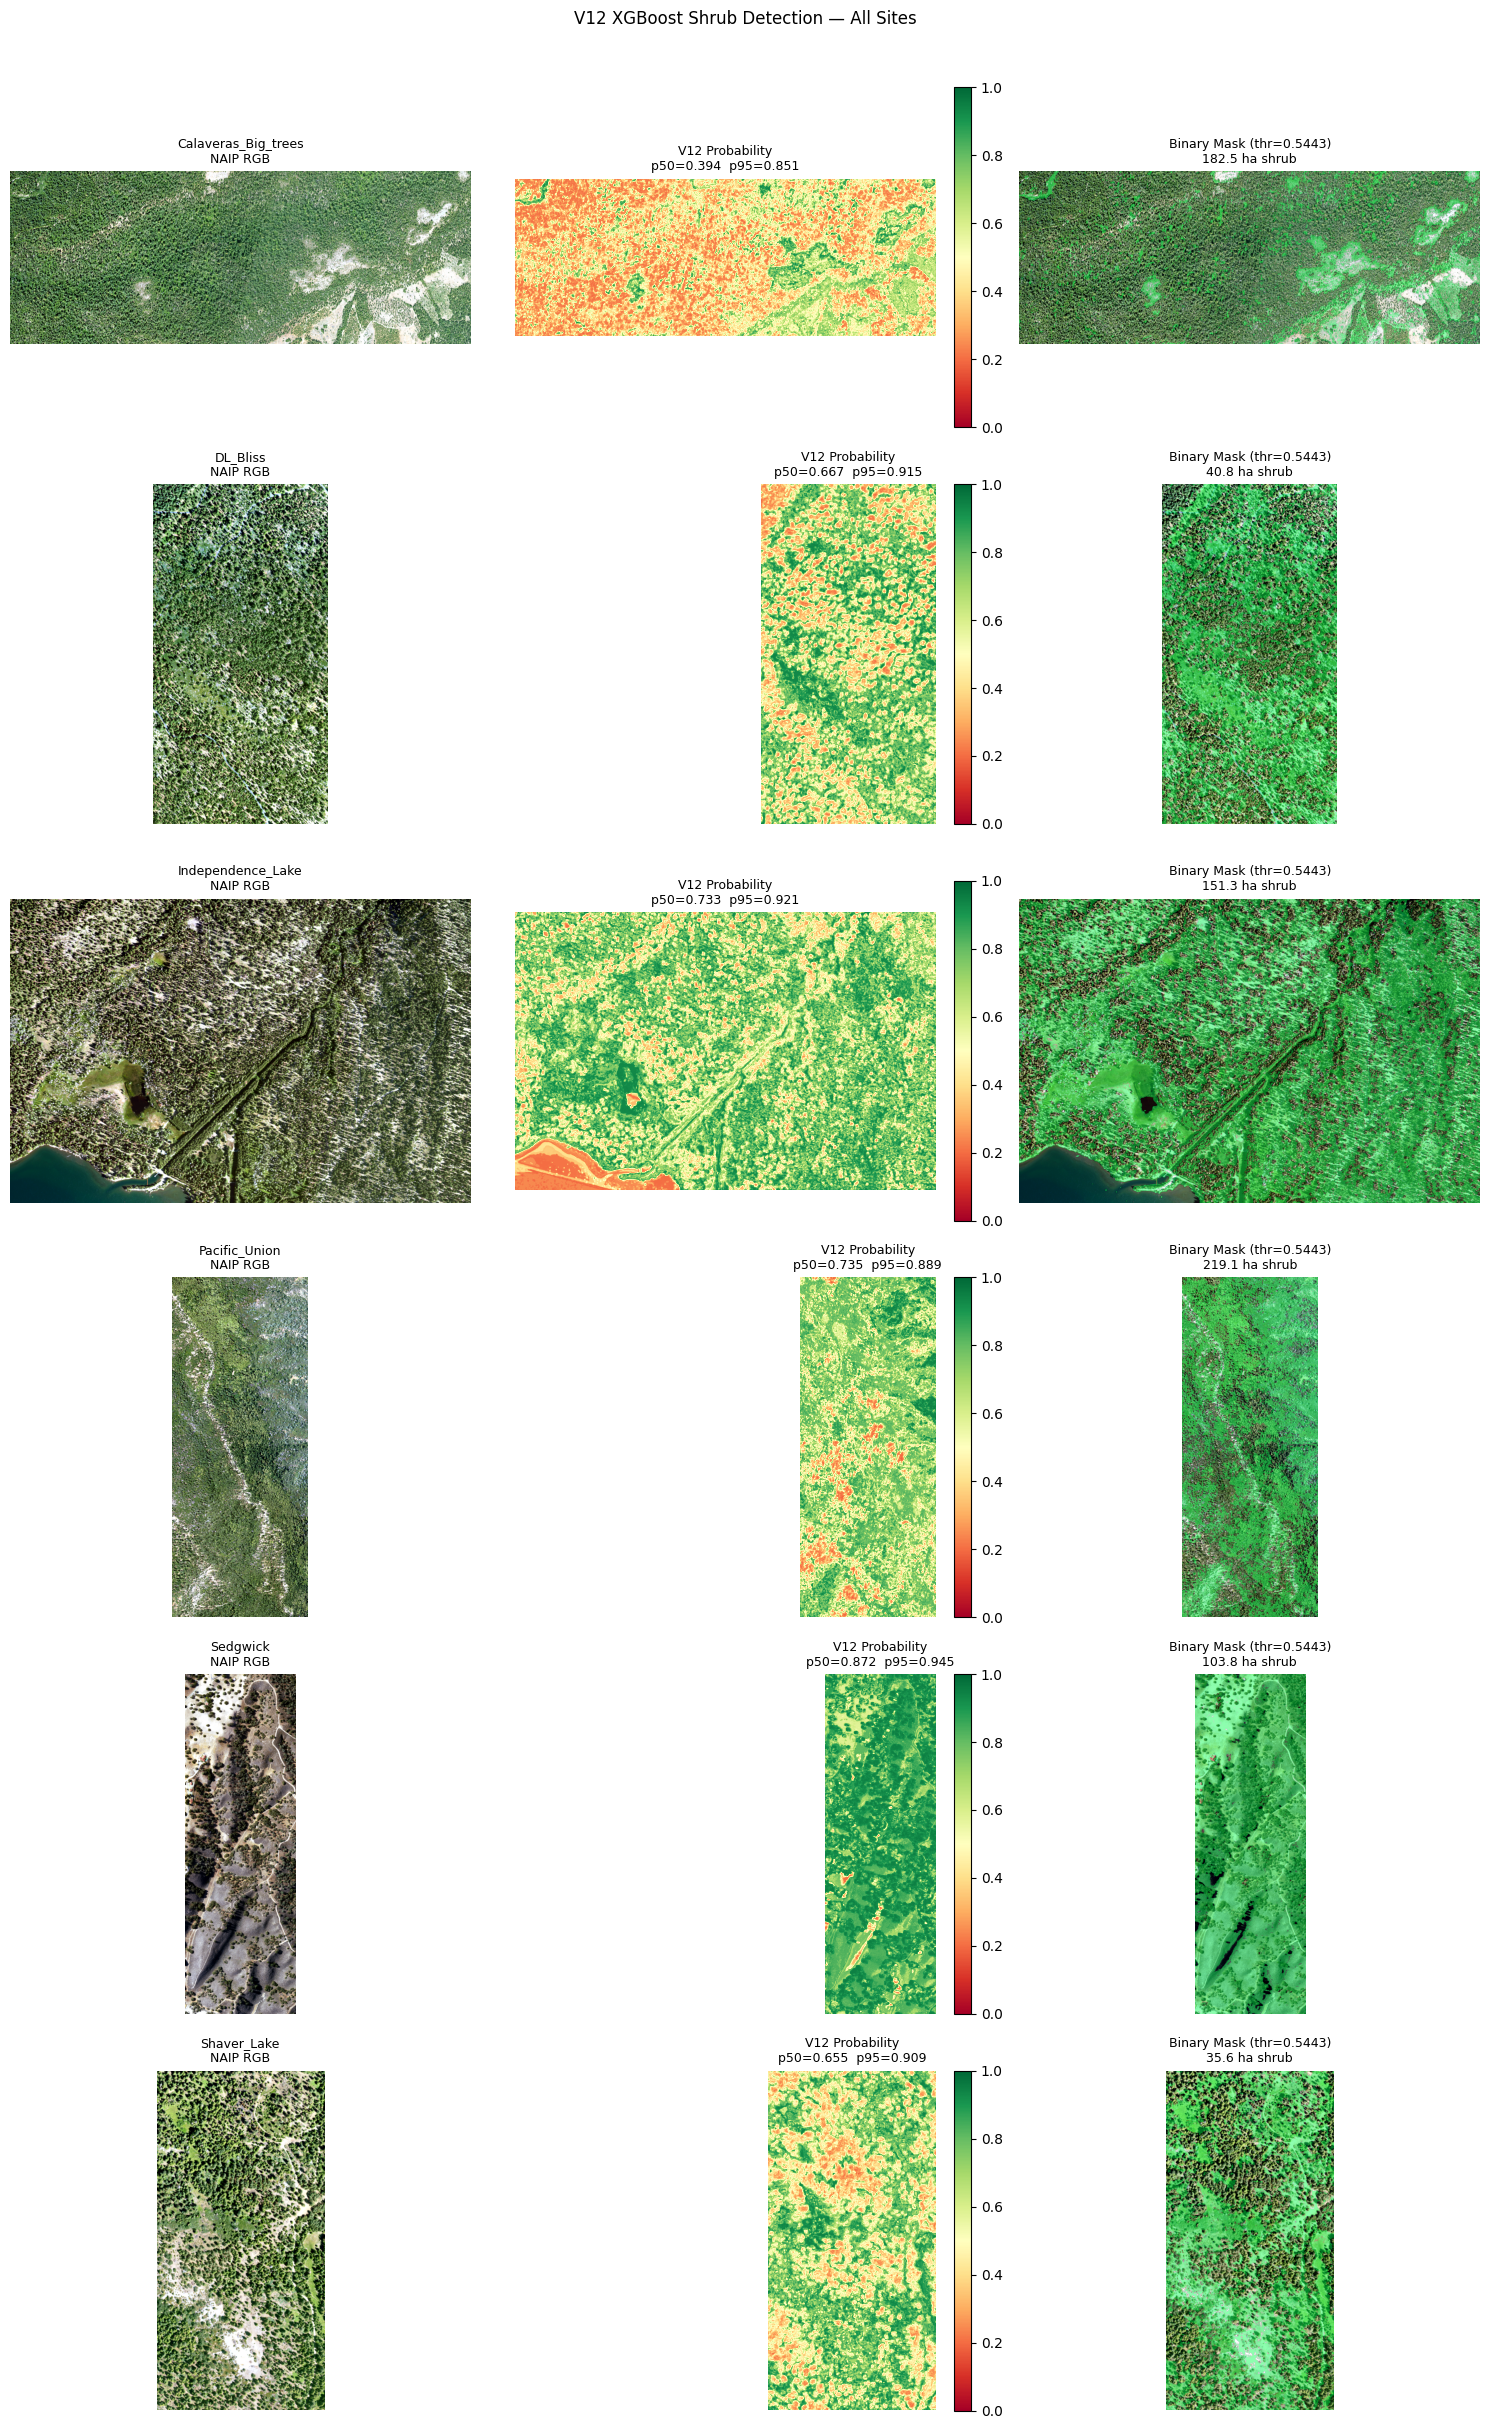

Saved: predictions_v12/all_sites_overview.png


In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio

def read_rgb(naip_path):
    with rasterio.open(naip_path) as src:
        r = src.read(1).astype(np.float32)
        g = src.read(2).astype(np.float32)
        b = src.read(3).astype(np.float32)
    rgb = np.stack([r, g, b], axis=-1)
    for c in range(3):
        lo, hi = np.percentile(rgb[..., c], [2, 98])
        if hi > lo:
            rgb[..., c] = np.clip((rgb[..., c] - lo) / (hi - lo), 0, 1)
        else:
            rgb[..., c] = 0
    return rgb

n_sites = len(results)
fig, axes = plt.subplots(n_sites, 3, figsize=(15, 4 * n_sites))
if n_sites == 1:
    axes = [axes]

for row, r in enumerate(results):
    site    = r["site"]
    cfg     = SITES[site]
    naip_p  = BASE / site / "NAIP_3DEP_product" / cfg["naip"]
    prob    = r["prob_map"]
    mask    = r["mask"]

    # Panel 1 — RGB
    rgb = read_rgb(naip_p)
    axes[row][0].imshow(rgb)
    axes[row][0].set_title(f"{site}\nNAIP RGB", fontsize=9)
    axes[row][0].axis("off")

    # Panel 2 — Probability map
    im = axes[row][1].imshow(prob, cmap="RdYlGn", vmin=0, vmax=1)
    plt.colorbar(im, ax=axes[row][1], fraction=0.046, pad=0.04)
    axes[row][1].set_title(f"V12 Probability\np50={r['p50']}  p95={r['p95']}", fontsize=9)
    axes[row][1].axis("off")

    # Panel 3 — Binary mask overlaid on RGB
    axes[row][2].imshow(rgb)
    shrub_overlay = np.zeros((*mask.shape, 4), dtype=np.float32)
    shrub_overlay[mask == 1] = [0.0, 1.0, 0.3, 0.45]   # green overlay
    axes[row][2].imshow(shrub_overlay)
    axes[row][2].set_title(f"Binary Mask (thr={meta['cls_threshold']})\n{r['shrub_ha']:.1f} ha shrub", fontsize=9)
    axes[row][2].axis("off")

plt.suptitle("V12 XGBoost Shrub Detection — All Sites", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(BASE / "predictions_v12" / "all_sites_overview.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: predictions_v12/all_sites_overview.png")

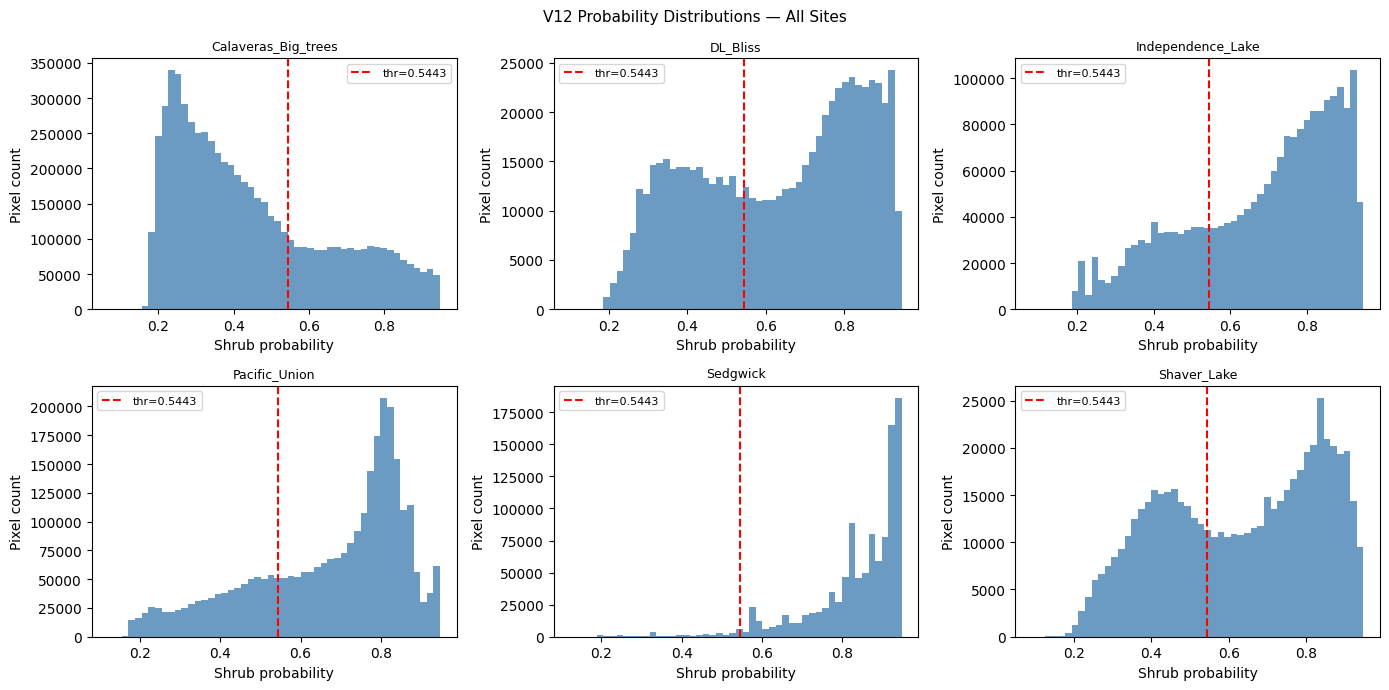

Saved: predictions_v12/probability_histograms.png


In [12]:
# Probability histograms per site
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, r in enumerate(results):
    ax   = axes[i]
    prob = r["prob_map"].flatten()
    ax.hist(prob, bins=50, color="steelblue", edgecolor="none", alpha=0.8)
    ax.axvline(meta["cls_threshold"], color="red", linestyle="--", label=f"thr={meta['cls_threshold']}")
    ax.set_title(r["site"], fontsize=9)
    ax.set_xlabel("Shrub probability")
    ax.set_ylabel("Pixel count")
    ax.legend(fontsize=8)

# Hide unused panels
for j in range(len(results), 6):
    axes[j].set_visible(False)

plt.suptitle("V12 Probability Distributions — All Sites", fontsize=11)
plt.tight_layout()
plt.savefig(BASE / "predictions_v12" / "probability_histograms.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: predictions_v12/probability_histograms.png")

---
## 7. Pipeline Complete

**Outputs written to `predictions_v12/`:**

| File | Description |
|---|---|
| `<site>/<site>_v12_prob.tif` | Float32 shrub probability map (0–1) |
| `<site>/<site>_v12_mask.tif` | Binary shrub mask (uint8, threshold=0.544) |
| `all_sites_overview.png` | RGB / prob / mask panels for all sites |
| `probability_histograms.png` | Per-site probability distributions |

**To run on a new AOI**, use the autonomous agent:
```bash
python Model_Prediction/autonomous_shrub_agent.py my_aoi.geojson --output results/
```

**To re-annotate with SAM** (requires checkpoint):
```bash
python sam_annotate.py --sites DL_Bliss --skip-amg
```

**To retrain V12:**
```bash
python train_shrub_v12.py
```